In [1]:
# ============================================================
# STAGE 8 — RECOMMENDATION & BUSINESS DECISION
# Tata Power EZ Charge — Demand Shifting
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. PATHS & INPUTS
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
OUTPUT_TABLE_PATH = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURE_PATH = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLE_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_PATH.mkdir(parents=True, exist_ok=True)

# Stage 4 — intervention opportunity
city_opportunity = pd.read_csv(
    OUTPUT_TABLE_PATH / "intervention_city_opportunity.csv"
)

segment_opportunity = pd.read_csv(
    OUTPUT_TABLE_PATH / "intervention_segment_opportunity.csv"
)

customer_priority = pd.read_csv(
    OUTPUT_TABLE_PATH / "intervention_customer_priority.csv"
)

# Stage 6 — experiment analysis
group_results = pd.read_csv(
    OUTPUT_TABLE_PATH / "experiment_group_results.csv"
)

segment_results = pd.read_csv(
    OUTPUT_TABLE_PATH / "experiment_segment_results.csv"
)

experiment_outcomes = pd.read_csv(
    OUTPUT_TABLE_PATH / "experiment_customer_outcomes.csv"
)

print("STAGE 8 INPUTS")
print("=" * 60)

print("City opportunity rows:", len(city_opportunity))
print("Segment opportunity rows:", len(segment_opportunity))
print("Customer priority rows:", len(customer_priority))
print("Experiment group rows:", len(group_results))
print("Experiment segment rows:", len(segment_results))
print("Experiment outcome rows:", len(experiment_outcomes))

STAGE 8 INPUTS
City opportunity rows: 12
Segment opportunity rows: 4
Customer priority rows: 8000
Experiment group rows: 2
Experiment segment rows: 8
Experiment outcome rows: 4661


In [2]:
# ============================================================
# 2. STANDARDISE COLUMN NAMES
# ============================================================

def find_col(df, candidates, required=True):
    """
    Find the first matching column from a list of possible names.
    """
    for col in candidates:
        if col in df.columns:
            return col

    if required:
        raise KeyError(
            f"Could not find any of {candidates}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    return None


# Segment opportunity
segment_col_opp = find_col(
    segment_opportunity,
    ["customer_segment", "customer_segment_x", "customer_segment_y"]
)

# Segment experiment results
segment_col_exp = find_col(
    segment_results,
    ["customer_segment", "customer_segment_x", "customer_segment_y"]
)

# City
city_col = find_col(
    city_opportunity,
    ["city", "city_x", "city_y"]
)

print("Detected columns:")
print("Segment opportunity:", segment_col_opp)
print("Segment experiment:", segment_col_exp)
print("City:", city_col)

Detected columns:
Segment opportunity: customer_segment_x
Segment experiment: customer_segment_x
City: city


In [3]:
# ============================================================
# 3. IDENTIFY BEST CUSTOMER SEGMENT
# ============================================================

# Experiment results contain the observed treatment response
segment_decision = segment_results.copy()

# Identify key metrics
response_col = find_col(
    segment_decision,
    ["response_rate_treatment", "response_rate"]
)

shift_col = find_col(
    segment_decision,
    [
        "session_shift_rate_treatment",
        "session_shift_rate",
        "shift_rate_treatment"
    ],
    required=False
)

customers_col = find_col(
    segment_decision,
    ["customers", "treatment_customers"],
    required=False
)

# If a treatment response column exists, rank on it
segment_decision["treatment_response"] = pd.to_numeric(
    segment_decision[response_col],
    errors="coerce"
)

if shift_col:
    segment_decision["treatment_shift_rate"] = pd.to_numeric(
        segment_decision[shift_col],
        errors="coerce"
    )
else:
    segment_decision["treatment_shift_rate"] = np.nan

# Rank primarily by treatment response
segment_decision = segment_decision.sort_values(
    "treatment_response",
    ascending=False
).reset_index(drop=True)

segment_decision["segment_rank"] = np.arange(
    1, len(segment_decision) + 1
)

print("SEGMENT RESPONSE")
print("=" * 60)

display_cols = [
    segment_col_exp,
    "treatment_response",
    "treatment_shift_rate",
    "segment_rank"
]

display(
    segment_decision[display_cols].round(4)
)

best_segment = segment_decision.iloc[0][segment_col_exp]

print("\nRecommended target segment:")
print(best_segment)

SEGMENT RESPONSE


,customer_segment_x,treatment_response,treatment_shift_rate,segment_rank
0,High_Mileage,0.3476,0.2410,1
1,Price_Sensitive,0.3098,0.1709,2
2,Routine_Commuter,0.2910,0.1343,3
3,High_Mileage,0.2751,0.1871,4
4,Convenience_First,0.2413,0.0930,5
5,Price_Sensitive,0.2103,0.1123,6
6,Routine_Commuter,0.1876,0.0887,7
7,Convenience_First,0.1573,0.0652,8



Recommended target segment:
High_Mileage


In [4]:
# ============================================================
# 4. IDENTIFY PRIORITY CITIES
# ============================================================

city_decision = city_opportunity.copy()

# Detect useful city metrics
score_col = find_col(
    city_decision,
    [
        "city_intervention_score",
        "avg_intervention_score",
        "intervention_score"
    ],
    required=False
)

eligible_col = find_col(
    city_decision,
    ["eligible_customers", "customers", "eligible"],
    required=False
)

shiftable_col = find_col(
    city_decision,
    [
        "estimated_shiftable_peak_sessions",
        "shiftable_peak_sessions",
        "peak_sessions"
    ],
    required=False
)

# Create a robust priority score
if score_col:
    city_decision["priority_score"] = pd.to_numeric(
        city_decision[score_col],
        errors="coerce"
    )
else:
    # Fallback: combine available opportunity indicators
    city_decision["priority_score"] = 0

    if eligible_col:
        city_decision["priority_score"] += (
            pd.to_numeric(city_decision[eligible_col], errors="coerce")
            .fillna(0)
            .rank(pct=True)
        )

    if shiftable_col:
        city_decision["priority_score"] += (
            pd.to_numeric(city_decision[shiftable_col], errors="coerce")
            .fillna(0)
            .rank(pct=True)
        )

city_decision = city_decision.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

city_decision["city_rank"] = np.arange(
    1,
    len(city_decision) + 1
)

print("CITY PRIORITISATION")
print("=" * 60)

city_display_cols = [
    city_col,
    "priority_score",
    "city_rank"
]

if eligible_col:
    city_display_cols.insert(1, eligible_col)

if shiftable_col:
    city_display_cols.insert(2, shiftable_col)

display(
    city_decision[city_display_cols].head(10).round(3)
)

priority_city = city_decision.iloc[0][city_col]

print("\nTop priority city:")
print(priority_city)

CITY PRIORITISATION


,city,eligible_customers,estimated_shiftable_peak_sessions,priority_score,city_rank
0,Delhi NCR,580,27069.453,49.245,1
1,Chennai,436,20427.643,49.223,2
2,Jaipur,255,12824.998,49.208,3
3,Hyderabad,437,22292.521,49.186,4
4,Bengaluru,569,26818.814,49.089,5
5,Kolkata,316,14674.287,49.074,6
6,Mumbai,537,25239.548,49.068,7
7,Kochi,235,11788.515,49.053,8
8,Lucknow,283,12838.991,48.912,9
9,Chandigarh,250,11386.503,48.884,10



Top priority city:
Delhi NCR


In [5]:
# ============================================================
# 5. FINAL INTERVENTION DECISION
# ============================================================

# Stage 7 economics
TREATMENT_CUSTOMERS = 2357
INCREMENTAL_SHIFTED_SESSIONS = 5235
INCREMENTAL_VALUE = 104700
INTERVENTION_COST = 11785
NET_INCREMENTAL_VALUE = INCREMENTAL_VALUE - INTERVENTION_COST

ROI = (
    NET_INCREMENTAL_VALUE / INTERVENTION_COST * 100
    if INTERVENTION_COST > 0
    else np.nan
)

BREAK_EVEN_VALUE_PER_SESSION = (
    INTERVENTION_COST / INCREMENTAL_SHIFTED_SESSIONS
    if INCREMENTAL_SHIFTED_SESSIONS > 0
    else np.nan
)

# Overall experiment response
treatment_row = group_results[
    group_results["experiment_group"] == "Treatment"
]

control_row = group_results[
    group_results["experiment_group"] == "Control"
]

if len(treatment_row) > 0 and len(control_row) > 0:

    treatment_shift_rate = treatment_row.iloc[0]["session_shift_rate"]
    control_shift_rate = control_row.iloc[0]["session_shift_rate"]

    observed_lift = treatment_shift_rate - control_shift_rate

else:
    treatment_shift_rate = np.nan
    control_shift_rate = np.nan
    observed_lift = np.nan


# ------------------------------------------------------------
# SCALE DECISION
# ------------------------------------------------------------

scale_decision = (
    "SCALE"
    if NET_INCREMENTAL_VALUE > 0 and ROI > 0
    else "DO NOT SCALE"
)

recommendation_summary = pd.DataFrame({
    "decision_area": [
        "Target segment",
        "Priority city",
        "Treatment shift rate",
        "Control shift rate",
        "Observed lift",
        "Incremental shifted sessions",
        "Incremental value",
        "Intervention cost",
        "Net incremental value",
        "ROI",
        "Break-even value/session",
        "Final scale decision"
    ],
    "value": [
        best_segment,
        priority_city,
        treatment_shift_rate,
        control_shift_rate,
        observed_lift,
        INCREMENTAL_SHIFTED_SESSIONS,
        INCREMENTAL_VALUE,
        INTERVENTION_COST,
        NET_INCREMENTAL_VALUE,
        ROI,
        BREAK_EVEN_VALUE_PER_SESSION,
        scale_decision
    ]
})

print("FINAL BUSINESS RECOMMENDATION")
print("=" * 60)

for _, row in recommendation_summary.iterrows():
    print(f"{row['decision_area']}: {row['value']}")

FINAL BUSINESS RECOMMENDATION
Target segment: High_Mileage
Priority city: Delhi NCR
Treatment shift rate: 0.1618741352877388
Control shift rate: 0.1151964757373203
Observed lift: 0.04667765955041851
Incremental shifted sessions: 5235
Incremental value: 104700
Intervention cost: 11785
Net incremental value: 92915
ROI: 788.4174798472634
Break-even value/session: 2.251193887297039
Final scale decision: SCALE


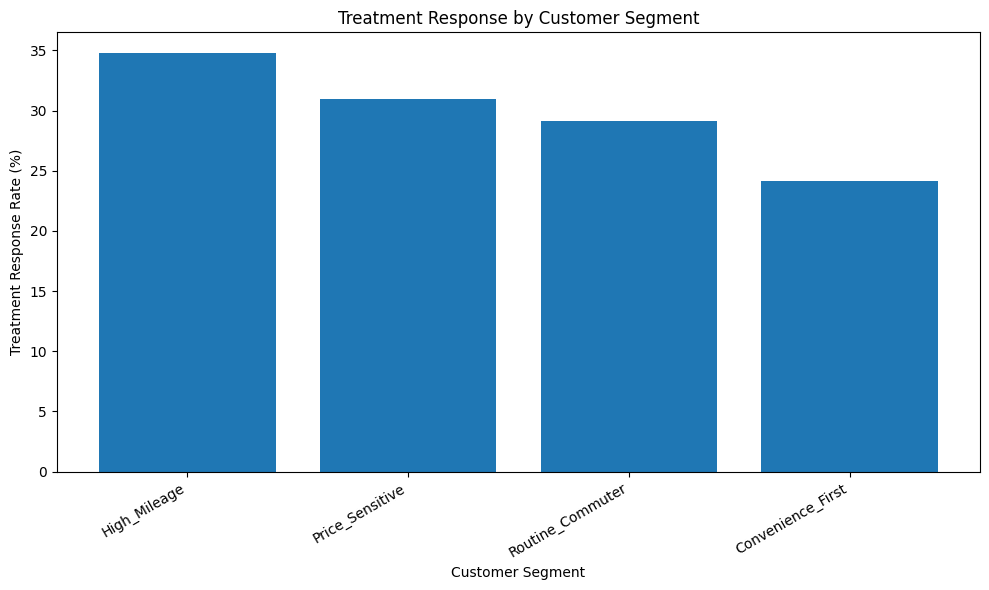


STAGE 8 — RECOMMENDATION COMPLETE
Recommended segment: High_Mileage
Priority city: Delhi NCR
Incremental shifted sessions: 5,235
Net incremental value: ₹92,915.00
ROI: 788.42%
Decision: SCALE

Outputs saved:
- final_segment_recommendation.csv
- final_city_recommendation.csv
- final_business_recommendation.csv
- recommendation_segment_response.png


In [6]:
# ============================================================
# 6. FINAL RECOMMENDATION VISUAL
# ============================================================

plot_segments = segment_decision.copy()

plot_segments["response_pct"] = (
    plot_segments["treatment_response"] * 100
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_segments[segment_col_exp].astype(str),
    plot_segments["response_pct"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Treatment Response Rate (%)")
plt.title("Treatment Response by Customer Segment")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_PATH / "recommendation_segment_response.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. SAVE RECOMMENDATION OUTPUTS
# ============================================================

segment_decision.to_csv(
    OUTPUT_TABLE_PATH / "final_segment_recommendation.csv",
    index=False
)

city_decision.to_csv(
    OUTPUT_TABLE_PATH / "final_city_recommendation.csv",
    index=False
)

recommendation_summary.to_csv(
    OUTPUT_TABLE_PATH / "final_business_recommendation.csv",
    index=False
)

print("\n" + "=" * 60)
print("STAGE 8 — RECOMMENDATION COMPLETE")
print("=" * 60)

print(f"Recommended segment: {best_segment}")
print(f"Priority city: {priority_city}")
print(f"Incremental shifted sessions: {INCREMENTAL_SHIFTED_SESSIONS:,}")
print(f"Net incremental value: ₹{NET_INCREMENTAL_VALUE:,.2f}")
print(f"ROI: {ROI:,.2f}%")
print(f"Decision: {scale_decision}")

print("\nOutputs saved:")
print("- final_segment_recommendation.csv")
print("- final_city_recommendation.csv")
print("- final_business_recommendation.csv")
print("- recommendation_segment_response.png")